In [1]:

#Cargar paquetes
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')


In [5]:
# Cargar archivo
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install -q kaggle

In [6]:
# cargar el dataset
!kaggle datasets download -d adilshamim8/social-media-addiction-vs-relationships

Dataset URL: https://www.kaggle.com/datasets/adilshamim8/social-media-addiction-vs-relationships
License(s): Attribution 4.0 International (CC BY 4.0)
  0% 0.00/7.67k [00:00<?, ?B/s]
100% 7.67k/7.67k [00:00<00:00, 17.7MB/s]


In [7]:
# descomprimir el archivo
!unzip social-media-addiction-vs-relationships.zip

Archive:  social-media-addiction-vs-relationships.zip
  inflating: Students Social Media Addiction.csv  


In [8]:
import pandas as pd
df = pd.read_csv('Students Social Media Addiction.csv')
df.head()


,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    705 non-null    int64  
 1   Age                           705 non-null    int64  
 2   Gender                        705 non-null    object 
 3   Academic_Level                705 non-null    object 
 4   Country                       705 non-null    object 
 5   Avg_Daily_Usage_Hours         705 non-null    float64
 6   Most_Used_Platform            705 non-null    object 
 7   Affects_Academic_Performance  705 non-null    object 
 8   Sleep_Hours_Per_Night         705 non-null    float64
 9   Mental_Health_Score           705 non-null    int64  
 10  Relationship_Status           705 non-null    object 
 11  Conflicts_Over_Social_Media   705 non-null    int64  
 12  Addicted_Score                705 non-null    int64  
dtypes: fl

## Preparación y limpieza de datos

In [10]:
# Identificación de valores nulos
valores_nan = df.isna()
valores_nan.head()

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False


In [11]:
cols_nan = valores_nan.any()
cols_con_nan = df.columns[cols_nan].tolist()
cols_con_nan

[]

In [ ]:
cont_valores_nan = valores_nan.sum()
cont_valores_nan

,0
Student_ID,0
Age,0
Gender,0
Academic_Level,0
Country,0
Avg_Daily_Usage_Hours,0
Most_Used_Platform,0
Affects_Academic_Performance,0
Sleep_Hours_Per_Night,0
Mental_Health_Score,0


### Análisis Exploratorio de los Datos (EDA)

In [12]:
# Análisis exploratorio
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Student_ID,705.0,353.000000,203.660256,1.0,177.0,353.0,529.0,705.0
Age,705.0,20.659574,1.399217,18.0,19.0,21.0,22.0,24.0
Avg_Daily_Usage_Hours,705.0,4.918723,1.257395,1.5,4.1,4.8,5.8,8.5
Sleep_Hours_Per_Night,705.0,6.868936,1.126848,3.8,6.0,6.9,7.7,9.6
Mental_Health_Score,705.0,6.226950,1.105055,4.0,5.0,6.0,7.0,9.0
Conflicts_Over_Social_Media,705.0,2.849645,0.957968,0.0,2.0,3.0,4.0,5.0
Addicted_Score,705.0,6.436879,1.587165,2.0,5.0,7.0,8.0,9.0


In [13]:
# Ver las columnas disponibles y sus tipos
print("Columnas del dataset:")
print(df.columns.tolist())
print("\nInformación general:")
print(df.info())
print("\nPrimeras filas:")
print(df.head())

Columnas del dataset:
['Student_ID', 'Age', 'Gender', 'Academic_Level', 'Country', 'Avg_Daily_Usage_Hours', 'Most_Used_Platform', 'Affects_Academic_Performance', 'Sleep_Hours_Per_Night', 'Mental_Health_Score', 'Relationship_Status', 'Conflicts_Over_Social_Media', 'Addicted_Score']

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    705 non-null    int64  
 1   Age                           705 non-null    int64  
 2   Gender                        705 non-null    object 
 3   Academic_Level                705 non-null    object 
 4   Country                       705 non-null    object 
 5   Avg_Daily_Usage_Hours         705 non-null    float64
 6   Most_Used_Platform            705 non-null    object 
 7   Affects_Academic_Performance  705 non-null    object 
 

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# configuracion de gráficos
plt.style.use('default')
sns.set_palette("Set2")



In [15]:
print("\n Información básica de nuestros datos")
print("-"*40)

print(f" Número total de estudiantes: {len(df)}")
print(f"Número de variables que medimos: {len(df.columns)}")


print("\n Las variables que tenemos son:")
for i, columna in enumerate(df.columns, 1):
    print(f"   {i}. {columna}")


 Información básica de nuestros datos
----------------------------------------
 Número total de estudiantes: 705
Número de variables que medimos: 13

 Las variables que tenemos son:
   1. Student_ID
   2. Age
   3. Gender
   4. Academic_Level
   5. Country
   6. Avg_Daily_Usage_Hours
   7. Most_Used_Platform
   8. Affects_Academic_Performance
   9. Sleep_Hours_Per_Night
   10. Mental_Health_Score
   11. Relationship_Status
   12. Conflicts_Over_Social_Media
   13. Addicted_Score


In [16]:
print("\n Variables númericas")
print("-"*40)

# Variables numéricas que nos interesan más
variables_importantes = ['Age', 'Avg_Daily_Usage_Hours', 'Mental_Health_Score', 'Addicted_Score']

print(" SIGNIFICADO DE CADA VARIABLE:")
print("   • Age: Edad del estudiante")
print("   • Avg_Daily_Usage_Hours: Horas que usa redes sociales por día")
print("   • Mental_Health_Score: Puntuación de salud mental (1-10)")
print("   • Addicted_Score: Nivel de adicción (1-10)")

print("\n ESTADÍSTICAS BÁSICAS:")
estadisticas = df[variables_importantes].describe()
print(estadisticas.round(1))


 Variables númericas
----------------------------------------
 SIGNIFICADO DE CADA VARIABLE:
   • Age: Edad del estudiante
   • Avg_Daily_Usage_Hours: Horas que usa redes sociales por día
   • Mental_Health_Score: Puntuación de salud mental (1-10)
   • Addicted_Score: Nivel de adicción (1-10)

 ESTADÍSTICAS BÁSICAS:
         Age  Avg_Daily_Usage_Hours  Mental_Health_Score  Addicted_Score
count  705.0                  705.0                705.0           705.0
mean    20.7                    4.9                  6.2             6.4
std      1.4                    1.3                  1.1             1.6
min     18.0                    1.5                  4.0             2.0
25%     19.0                    4.1                  5.0             5.0
50%     21.0                    4.8                  6.0             7.0
75%     22.0                    5.8                  7.0             8.0
max     24.0                    8.5                  9.0             9.0


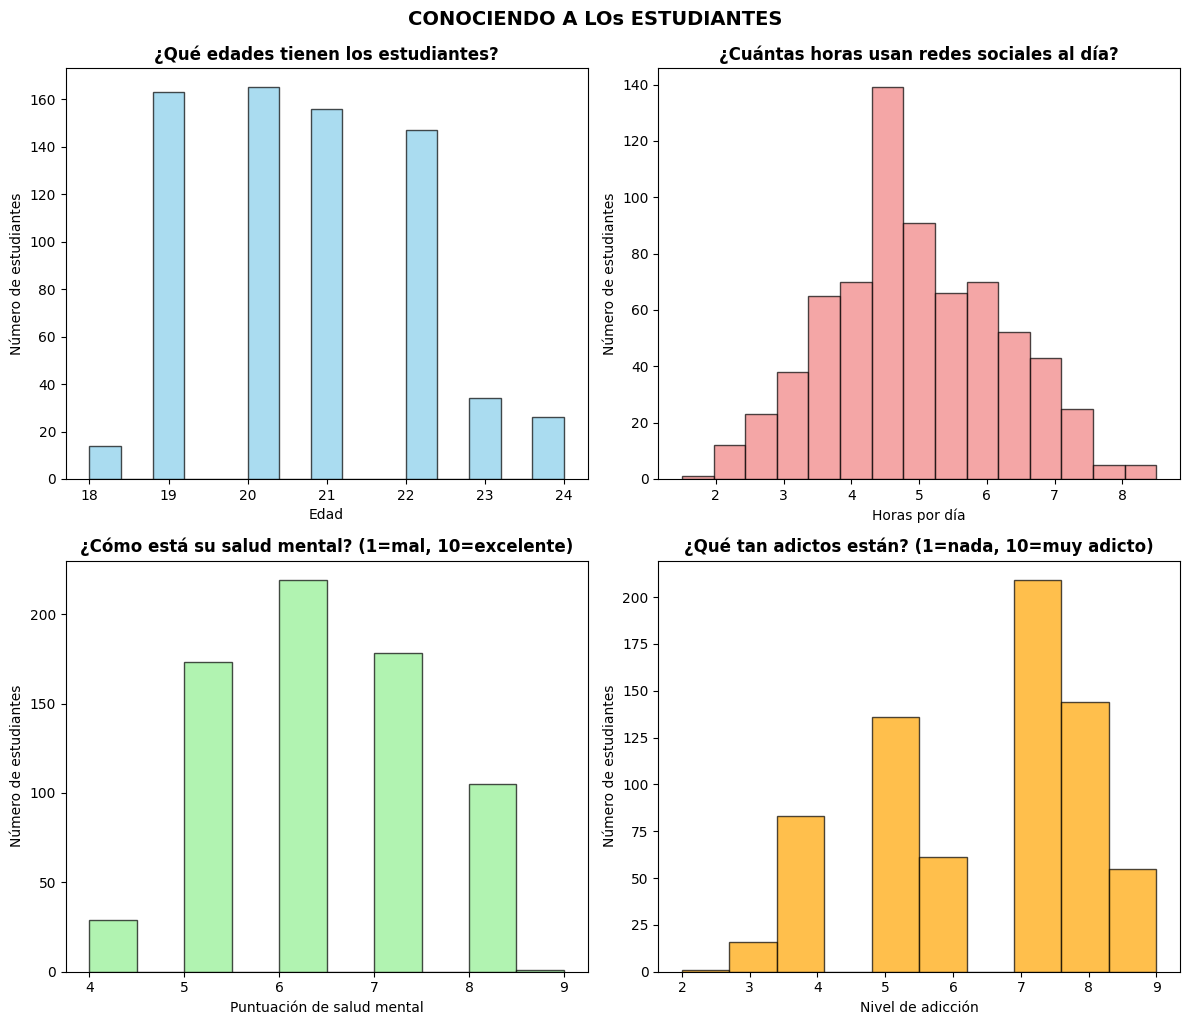

In [17]:



fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Grafica 1: Edades de los estudiantes
axes[0,0].hist(df['Age'], bins=15, color='skyblue', alpha=0.7, edgecolor='black')
axes[0,0].set_title('¿Qué edades tienen los estudiantes?', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Edad')
axes[0,0].set_ylabel('Número de estudiantes')

#Grafica 2: Horas diarias en redes sociales
axes[0,1].hist(df['Avg_Daily_Usage_Hours'], bins=15, color='lightcoral', alpha=0.7, edgecolor='black')
axes[0,1].set_title('¿Cuántas horas usan redes sociales al día?', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Horas por día')
axes[0,1].set_ylabel('Número de estudiantes')

# Grafica 3: Puntuación de salud mental
axes[1,0].hist(df['Mental_Health_Score'], bins=10, color='lightgreen', alpha=0.7, edgecolor='black')
axes[1,0].set_title('¿Cómo está su salud mental? (1=mal, 10=excelente)', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Puntuación de salud mental')
axes[1,0].set_ylabel('Número de estudiantes')

# Grafica 4: Nivel de adicción
axes[1,1].hist(df['Addicted_Score'], bins=10, color='orange', alpha=0.7, edgecolor='black')
axes[1,1].set_title('¿Qué tan adictos están? (1=nada, 10=muy adicto)', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Nivel de adicción')
axes[1,1].set_ylabel('Número de estudiantes')

plt.tight_layout()
plt.suptitle('CONOCIENDO A LOs ESTUDIANTES',
             fontsize=14, fontweight='bold', y=1.02)
plt.show()



In [18]:
# datos interesantes
edad_promedio = df['Age'].mean()
horas_promedio = df['Avg_Daily_Usage_Hours'].mean()
salud_mental_promedio = df['Mental_Health_Score'].mean()
adiccion_promedio = df['Addicted_Score'].mean()

print(f"El estudiante promedio tiene {edad_promedio:.1f} años")
print(f"Usa redes sociales {horas_promedio:.1f} horas por día")
print(f"Su salud mental está en {salud_mental_promedio:.1f}/10")
print(f"Su nivel de adicción está en {adiccion_promedio:.1f}/10")


El estudiante promedio tiene 20.7 años
Usa redes sociales 4.9 horas por día
Su salud mental está en 6.2/10
Su nivel de adicción está en 6.4/10


In [19]:
print(f"\n ALGUNOS OTROS DATOS:")
print(f"   • El que más usa redes sociales: {df['Avg_Daily_Usage_Hours'].max():.1f} horas/día")
print(f"   • El que menos usa redes sociales: {df['Avg_Daily_Usage_Hours'].min():.1f} horas/día")
print(f"   • Nivel más alto de adicción: {df['Addicted_Score'].max()}/10")
print(f"   • Nivel más bajo de adicción: {df['Addicted_Score'].min()}/10")


 ALGUNOS OTROS DATOS:
   • El que más usa redes sociales: 8.5 horas/día
   • El que menos usa redes sociales: 1.5 horas/día
   • Nivel más alto de adicción: 9/10
   • Nivel más bajo de adicción: 2/10


### RELACIONES ENTRE LAS VARIABLES

In [20]:
print("¿Qué vamos a buscar?")
print(" CORRELACIÓN = ¿Se mueven juntas dos variables?")
print("   • Si una sube, ¿la otra también sube? = CORRELACIÓN POSITIVA")
print("   • Si una sube, ¿la otra baja? = CORRELACIÓN NEGATIVA")
print("   • ¿No se afectan entre sí? = SIN CORRELACIÓN")
print("\n ESCALA:")
print("   • +1.0 = correlación positiva")
print("   • 0.0 = No hay correlación")
print("   • -1.0 = Correlación negativa")

¿Qué vamos a buscar?
 CORRELACIÓN = ¿Se mueven juntas dos variables?
   • Si una sube, ¿la otra también sube? = CORRELACIÓN POSITIVA
   • Si una sube, ¿la otra baja? = CORRELACIÓN NEGATIVA
   • ¿No se afectan entre sí? = SIN CORRELACIÓN

 ESCALA:
   • +1.0 = correlación positiva
   • 0.0 = No hay correlación
   • -1.0 = Correlación negativa



 Calculando conexiones importantes
Correlaciones calculadas. Ahora vamos a visualizarlas...

 Mapa de calor de correlaciones


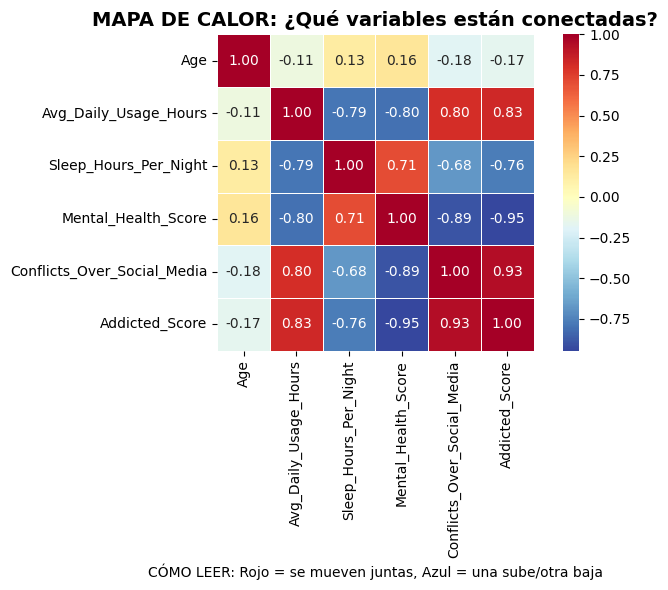

In [21]:
print("\n Calculando conexiones importantes")

# Variables a analizar
variables_principales = [
    'Age',                          # Edad
    'Avg_Daily_Usage_Hours',        # Horas por día
    'Sleep_Hours_Per_Night',        # Horas de sueño
    'Mental_Health_Score',          # Salud mental
    'Conflicts_Over_Social_Media',  # Conflictos por redes sociales
    'Addicted_Score'                # Nivel de adicción
]

# Calcular correlaciones
correlaciones = df[variables_principales].corr()

print("Correlaciones calculadas. Ahora vamos a visualizarlas...")

print("\n Mapa de calor de correlaciones")


plt.figure(figsize=(8, 6))

sns.heatmap(correlaciones,
            annot=True,           # Mostrar números
            cmap='RdYlBu_r',      # Colores: rojo=positivo, azul=negativo
            center=0,             # Centrar en 0
            square=True,          # Hacer cuadrados
            fmt='.2f',            # 2 decimales
            linewidths=0.5)       # Líneas entre celdas

plt.title('MAPA DE CALOR: ¿Qué variables están conectadas?',
          fontsize=14, fontweight='bold')
plt.xlabel('CÓMO LEER: Rojo = se mueven juntas, Azul = una sube/otra baja')
plt.tight_layout()
plt.show()

In [23]:
correlaciones_adiccion = correlaciones['Addicted_Score'].drop('Addicted_Score')
# Ordenar por importancia (valor absoluto)
correlaciones_adiccion = correlaciones_adiccion.reindex(
    correlaciones_adiccion.abs().sort_values(ascending=False).index
)

print("FACTORES QUE MÁS AFECTAN LA ADICCIÓN:")
print("   (Números más altos = mayor conexión)")
print()

for i, (variable, valor) in enumerate(correlaciones_adiccion.items(), 1):
    # Poniendo los nombres en español
    nombres_spanish = {
        'Avg_Daily_Usage_Hours': 'Horas diarias en redes sociales',
        'Conflicts_Over_Social_Media': 'Conflictos por redes sociales',
        'Mental_Health_Score': 'Salud mental',
        'Sleep_Hours_Per_Night': 'Horas de sueño por noche',
        'Age': 'Edad'
    }

    nombre_español = nombres_spanish.get(variable, variable)

    # Interpretando el valor
    if valor > 0.3:
        interpretacion = "FUERTE correlación"
    elif valor > 0.1:
        interpretacion = "Correlación positiva moderada"
    elif valor > -0.1:
        interpretacion = "Poca o ninguna correlación"
    elif valor > -0.3:
        interpretacion = "Correlacion negativa moderada"
    else:
        interpretacion = "FUERTE correlación negativa"

    print(f"   {i}. {nombre_español:<35}: {valor:>6.3f} - {interpretacion}")

FACTORES QUE MÁS AFECTAN LA ADICCIÓN:
   (Números más altos = mayor conexión)

   1. Salud mental                       : -0.945 - FUERTE correlación negativa
   2. Conflictos por redes sociales      :  0.934 - FUERTE correlación
   3. Horas diarias en redes sociales    :  0.832 - FUERTE correlación
   4. Horas de sueño por noche           : -0.765 - FUERTE correlación negativa
   5. Edad                               : -0.166 - Correlacion negativa moderada



 Graficas para VER las conexiones más importantes


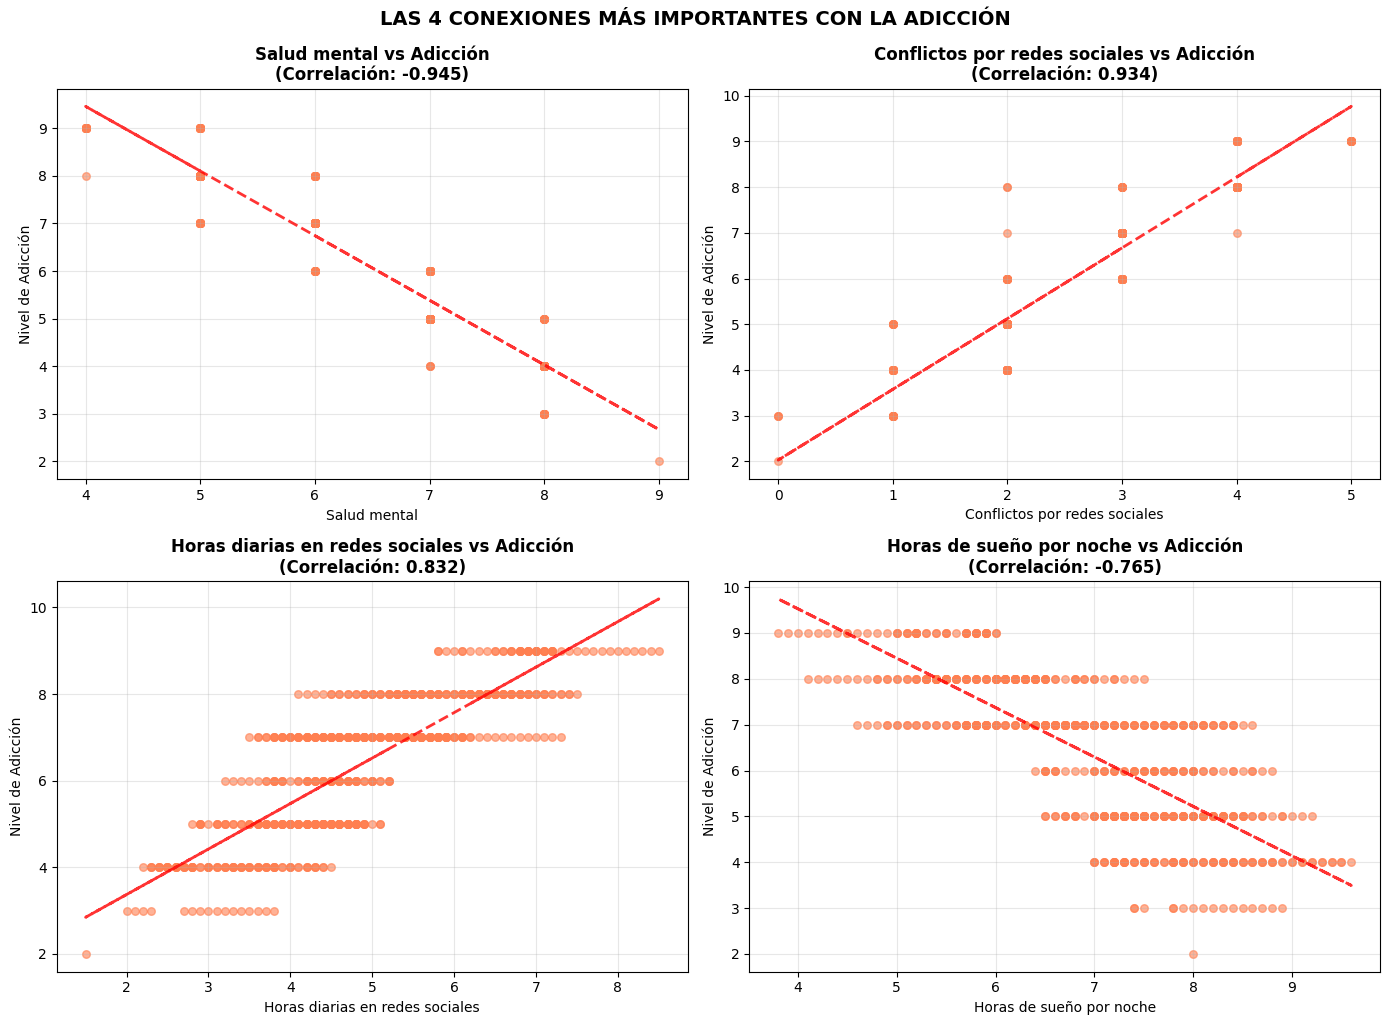

In [24]:
print(f"\n Graficas para VER las conexiones más importantes")


# Encontrar las 4 correlaciones más fuertes con adicción
top_4_variables = correlaciones_adiccion.abs().nlargest(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, variable in enumerate(top_4_variables):

    nombres_spanish = {
        'Avg_Daily_Usage_Hours': 'Horas diarias en redes sociales',
        'Conflicts_Over_Social_Media': 'Conflictos por redes sociales',
        'Mental_Health_Score': 'Salud mental',
        'Sleep_Hours_Per_Night': 'Horas de sueño por noche',
        'Age': 'Edad'
    }

    nombre_español = nombres_spanish.get(variable, variable)
    correlacion = correlaciones_adiccion[variable]

    # gráfico de dispersión
    axes[i].scatter(df[variable], df['Addicted_Score'],
                   alpha=0.6, color='coral', s=30)

    # Agregar línea de tendencia
    z = np.polyfit(df[variable], df['Addicted_Score'], 1)
    p = np.poly1d(z)
    axes[i].plot(df[variable], p(df[variable]), "r--", alpha=0.8, linewidth=2)

    axes[i].set_xlabel(nombre_español)
    axes[i].set_ylabel('Nivel de Adicción')
    axes[i].set_title(f'{nombre_español} vs Adicción\n(Correlación: {correlacion:.3f})',
                     fontweight='bold')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('LAS 4 CONEXIONES MÁS IMPORTANTES CON LA ADICCIÓN',
             fontsize=14, fontweight='bold', y=1.02)
plt.show()

In [25]:
print(f"\n ¿Qué significan estos resultados?")


# La correlación más fuerte
variable_mas_fuerte = correlaciones_adiccion.abs().idxmax()
valor_mas_fuerte = correlaciones_adiccion[variable_mas_fuerte]

nombres_spanish = {
    'Avg_Daily_Usage_Hours': 'las horas diarias en redes sociales',
    'Conflicts_Over_Social_Media': 'los conflictos por redes sociales',
    'Mental_Health_Score': 'la salud mental',
    'Sleep_Hours_Per_Night': 'las horas de sueño',
    'Age': 'la edad'
}

variable_español = nombres_spanish.get(variable_mas_fuerte, variable_mas_fuerte)

print(f" DESCUBRIMIENTO PRINCIPAL:")
print(f" El factor más conectado con la adicción es: {variable_español}")
print(f" Correlación: {valor_mas_fuerte:.3f}")

if valor_mas_fuerte > 0:
    print(f"  Esto significa: Cuando {variable_español} aumentan, la adicción también aumenta")
else:
    print(f"  Esto significa: Cuando {variable_español} aumenta, la adicción disminuye")

print(f"\n OTROS DESCUBRIMIENTOS IMPORTANTES:")

# Las otras correlaciones fuertes
for variable, valor in correlaciones_adiccion.items():
    if abs(valor) > 0.3 and variable != variable_mas_fuerte:
        var_esp = nombres_spanish.get(variable, variable)
        if valor > 0:
            print(f"   • {var_esp.capitalize()} también aumenta con la adicción ({valor:.3f})")
        else:
            print(f"   • {var_esp.capitalize()} disminuye cuando hay más adicción ({valor:.3f})")



 ¿Qué significan estos resultados?
 DESCUBRIMIENTO PRINCIPAL:
 El factor más conectado con la adicción es: la salud mental
 Correlación: -0.945
  Esto significa: Cuando la salud mental aumenta, la adicción disminuye

 OTROS DESCUBRIMIENTOS IMPORTANTES:
   • Los conflictos por redes sociales también aumenta con la adicción (0.934)
   • Las horas diarias en redes sociales también aumenta con la adicción (0.832)
   • Las horas de sueño disminuye cuando hay más adicción (-0.765)


### Comparativas con distintos tipos de estudiantes

In [26]:
print("PREGUNTAS A RESPONDER:")
print("   1. ¿Los hombres y mujeres tienen diferente nivel de adicción?")
print("   2. ¿Los estudiantes universitarios son más adictos que los de preparatoria?")
print("   3. ¿Qué plataforma de redes sociales genera más adicción?")
print("   4. ¿El estado civil influye en la adicción?")

PREGUNTAS A RESPONDER:
   1. ¿Los hombres y mujeres tienen diferente nivel de adicción?
   2. ¿Los estudiantes universitarios son más adictos que los de preparatoria?
   3. ¿Qué plataforma de redes sociales genera más adicción?
   4. ¿El estado civil influye en la adicción?



 COMPARANDO HOMBRES vs MUJERES
ESTADÍSTICAS POR GÉNERO:
HOMBRES (352 estudiantes):
   • Adicción promedio: 6.36/10
   • Horas diarias: 4.83
   • Salud mental: 6.28/10

 MUJERES (353 estudiantes):
   • Adicción promedio: 6.52/10
   • Horas diarias: 5.01
   • Salud mental: 6.18/10


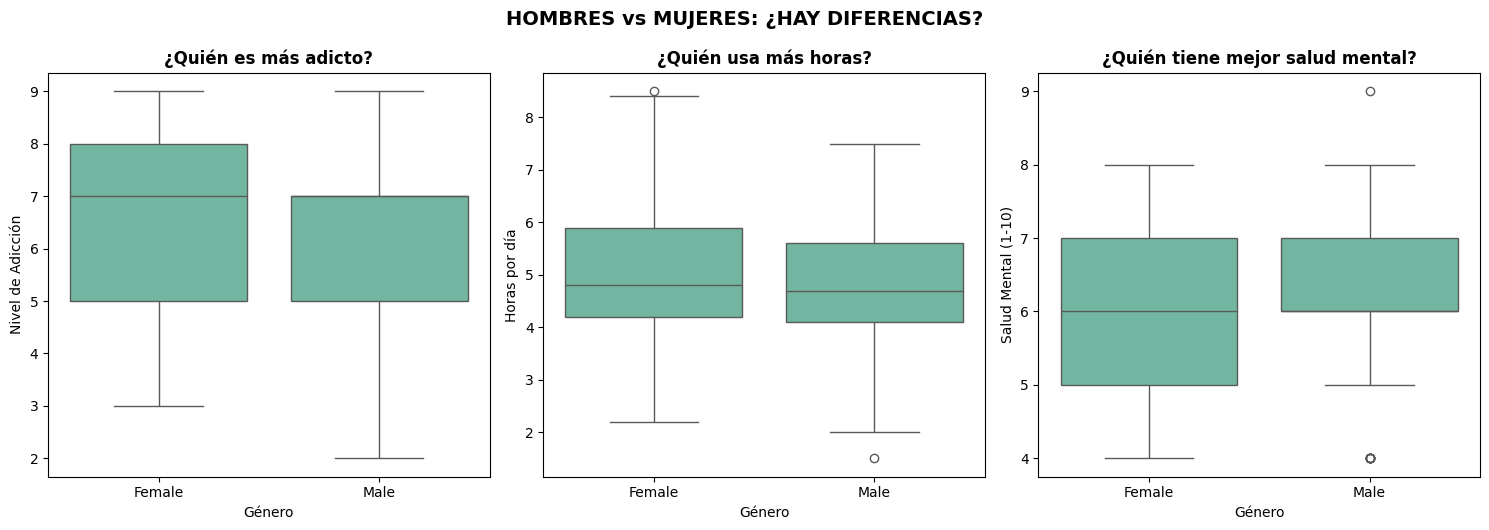

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("\n COMPARANDO HOMBRES vs MUJERES")


# Las estadísticas por genero
stats_genero = df.groupby('Gender').agg({
    'Addicted_Score': ['mean', 'std', 'count'],
    'Avg_Daily_Usage_Hours': 'mean',
    'Mental_Health_Score': 'mean',
    'Conflicts_Over_Social_Media': 'mean'
}).round(2)

print("ESTADÍSTICAS POR GÉNERO:")
print(f"HOMBRES ({df[df['Gender']=='Male'].shape[0]} estudiantes):")
print(f"   • Adicción promedio: {df[df['Gender']=='Male']['Addicted_Score'].mean():.2f}/10")
print(f"   • Horas diarias: {df[df['Gender']=='Male']['Avg_Daily_Usage_Hours'].mean():.2f}")
print(f"   • Salud mental: {df[df['Gender']=='Male']['Mental_Health_Score'].mean():.2f}/10")

print(f"\n MUJERES ({df[df['Gender']=='Female'].shape[0]} estudiantes):")
print(f"   • Adicción promedio: {df[df['Gender']=='Female']['Addicted_Score'].mean():.2f}/10")
print(f"   • Horas diarias: {df[df['Gender']=='Female']['Avg_Daily_Usage_Hours'].mean():.2f}")
print(f"   • Salud mental: {df[df['Gender']=='Female']['Mental_Health_Score'].mean():.2f}/10")

# Gráfico comparativo hombres vs mujeres
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Grafica 1: Nivel de adicción
sns.boxplot(data=df, x='Gender', y='Addicted_Score', ax=axes[0])
axes[0].set_title('¿Quién es más adicto?', fontweight='bold')
axes[0].set_xlabel('Género')
axes[0].set_ylabel('Nivel de Adicción')

# Grafica 2: Horas diarias
sns.boxplot(data=df, x='Gender', y='Avg_Daily_Usage_Hours', ax=axes[1])
axes[1].set_title('¿Quién usa más horas?', fontweight='bold')
axes[1].set_xlabel('Género')
axes[1].set_ylabel('Horas por día')

# Grafica 3: Salud mental
sns.boxplot(data=df, x='Gender', y='Mental_Health_Score', ax=axes[2])
axes[2].set_title('¿Quién tiene mejor salud mental?', fontweight='bold')
axes[2].set_xlabel('Género')
axes[2].set_ylabel('Salud Mental (1-10)')

plt.tight_layout()
plt.suptitle('HOMBRES vs MUJERES: ¿HAY DIFERENCIAS?', fontsize=14, fontweight='bold', y=1.05)
plt.show()


### Comparando por nivel académico

NIVELES ACADÉMICOS EN NUESTRA MUESTRA:
   Undergraduate: 353 estudiantes
   Graduate: 325 estudiantes
   High School: 27 estudiantes

ADICCIÓN PROMEDIO POR NIVEL:
   Undergraduate: 6.49/10 (usan 5.0h/día)
   Graduate: 6.24/10 (usan 4.8h/día)
   High School: 8.04/10 (usan 5.5h/día)


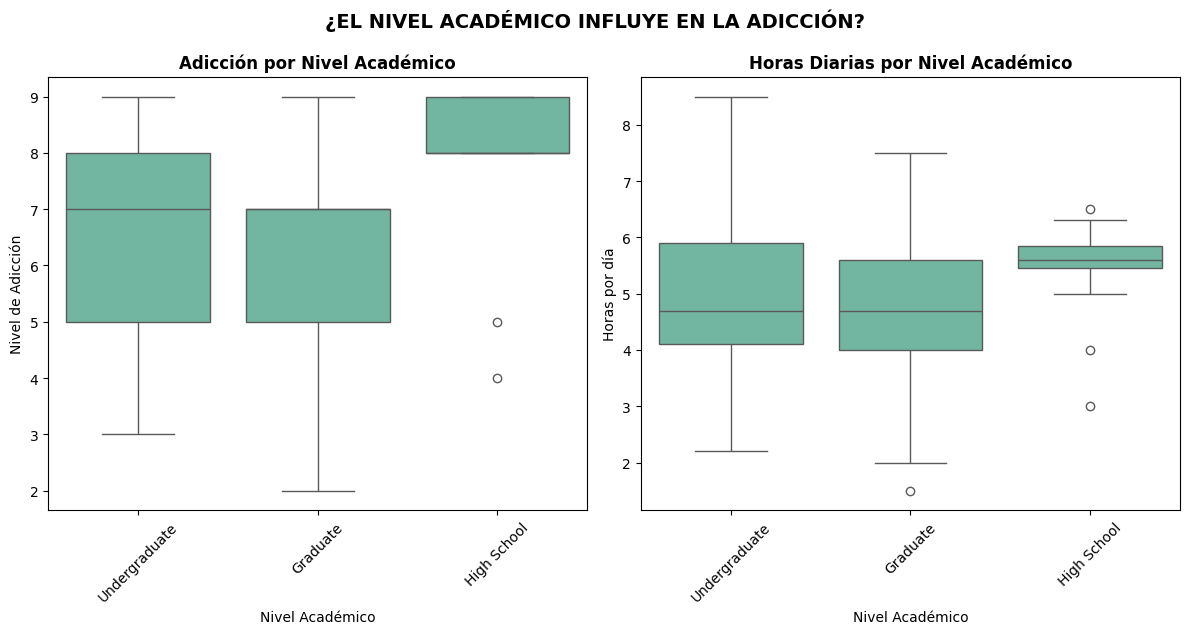

In [28]:
# Ver qué niveles académicos tenemos
niveles_academicos = df['Academic_Level'].value_counts()
print("NIVELES ACADÉMICOS EN NUESTRA MUESTRA:")
for nivel, cantidad in niveles_academicos.items():
    print(f"   {nivel}: {cantidad} estudiantes")

# Estadísticas por nivel académico
print("\nADICCIÓN PROMEDIO POR NIVEL:")
for nivel in df['Academic_Level'].unique():
    estudiantes_nivel = df[df['Academic_Level'] == nivel]
    adiccion_promedio = estudiantes_nivel['Addicted_Score'].mean()
    horas_promedio = estudiantes_nivel['Avg_Daily_Usage_Hours'].mean()
    print(f"   {nivel}: {adiccion_promedio:.2f}/10 (usan {horas_promedio:.1f}h/día)")

# Gráfico por nivel académico
plt.figure(figsize=(12, 6))

# Subplot 1: Adicción por nivel
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='Academic_Level', y='Addicted_Score')
plt.title('Adicción por Nivel Académico', fontweight='bold')
plt.xlabel('Nivel Académico')
plt.ylabel('Nivel de Adicción')
plt.xticks(rotation=45)

# Subplot 2: Horas por nivel
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Academic_Level', y='Avg_Daily_Usage_Hours')
plt.title('Horas Diarias por Nivel Académico', fontweight='bold')
plt.xlabel('Nivel Académico')
plt.ylabel('Horas por día')
plt.xticks(rotation=45)

plt.tight_layout()
plt.suptitle('¿EL NIVEL ACADÉMICO INFLUYE EN LA ADICCIÓN?', fontsize=14, fontweight='bold', y=1.05)
plt.show()

### ¿Qué plataforma genera mayor adicción?

PLATAFORMAS MÁS USADAS:
   • Instagram: 249 estudiantes
   • TikTok: 154 estudiantes
   • Facebook: 123 estudiantes
   • WhatsApp: 54 estudiantes
   • Twitter: 30 estudiantes
   • LinkedIn: 21 estudiantes
   • WeChat: 15 estudiantes
   • Snapchat: 13 estudiantes
   • VKontakte: 12 estudiantes
   • LINE: 12 estudiantes
   • KakaoTalk: 12 estudiantes
   • YouTube: 10 estudiantes

NIVEL DE ADICCIÓN POR PLATAFORMA:
   Instagram: 6.55/10 (usan 4.9h/día)
   Twitter: 5.50/10 (usan 4.9h/día)
   TikTok: 7.43/10 (usan 5.3h/día)
   YouTube: 6.10/10 (usan 4.1h/día)
   Facebook: 5.67/10 (usan 4.5h/día)
   LinkedIn: 3.81/10 (usan 2.5h/día)
   Snapchat: 7.46/10 (usan 5.1h/día)
   LINE: 3.00/10 (usan 3.2h/día)
   KakaoTalk: 6.00/10 (usan 4.7h/día)
   VKontakte: 5.00/10 (usan 4.2h/día)
   WhatsApp: 7.46/10 (usan 6.5h/día)
   WeChat: 6.07/10 (usan 5.0h/día)


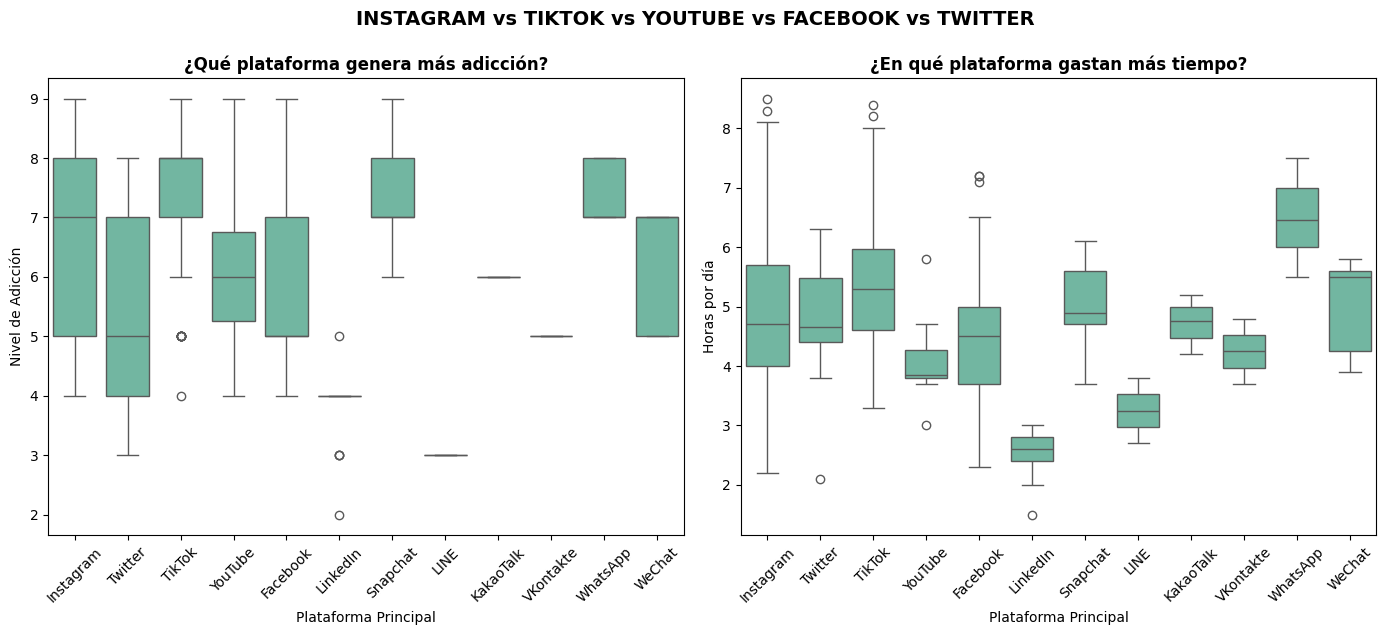

In [29]:
# Ver qué plataformas tenemos
plataformas = df['Most_Used_Platform'].value_counts()
print("PLATAFORMAS MÁS USADAS:")
for plataforma, cantidad in plataformas.items():
    print(f"   • {plataforma}: {cantidad} estudiantes")

# Adicción promedio por plataforma
print("\nNIVEL DE ADICCIÓN POR PLATAFORMA:")
for plataforma in df['Most_Used_Platform'].unique():
    usuarios_plataforma = df[df['Most_Used_Platform'] == plataforma]
    adiccion_promedio = usuarios_plataforma['Addicted_Score'].mean()
    horas_promedio = usuarios_plataforma['Avg_Daily_Usage_Hours'].mean()
    print(f"   {plataforma}: {adiccion_promedio:.2f}/10 (usan {horas_promedio:.1f}h/día)")

# Gráfico por plataforma
plt.figure(figsize=(14, 6))

# Subplot 1: Adicción por plataforma
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='Most_Used_Platform', y='Addicted_Score')
plt.title('¿Qué plataforma genera más adicción?', fontweight='bold')
plt.xlabel('Plataforma Principal')
plt.ylabel('Nivel de Adicción')
plt.xticks(rotation=45)

# Subplot 2: Horas por plataforma
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Most_Used_Platform', y='Avg_Daily_Usage_Hours')
plt.title('¿En qué plataforma gastan más tiempo?', fontweight='bold')
plt.xlabel('Plataforma Principal')
plt.ylabel('Horas por día')
plt.xticks(rotation=45)

plt.tight_layout()
plt.suptitle('INSTAGRAM vs TIKTOK vs YOUTUBE vs FACEBOOK vs TWITTER', fontsize=14, fontweight='bold', y=1.05)
plt.show()

### ¿El estado civil influye en la adicción a las redes sociales?

ESTADOS CIVILES EN NUESTRA MUESTRA:
   • Single: 384 estudiantes
   • In Relationship: 289 estudiantes
   • Complicated: 32 estudiantes

ADICCIÓN Y CONFLICTOS POR ESTADO CIVIL:
   In Relationship: Adicción 6.34/10, Conflictos 2.8
   Single: Adicción 6.46/10, Conflictos 2.9
   Complicated: Adicción 7.03/10, Conflictos 3.0


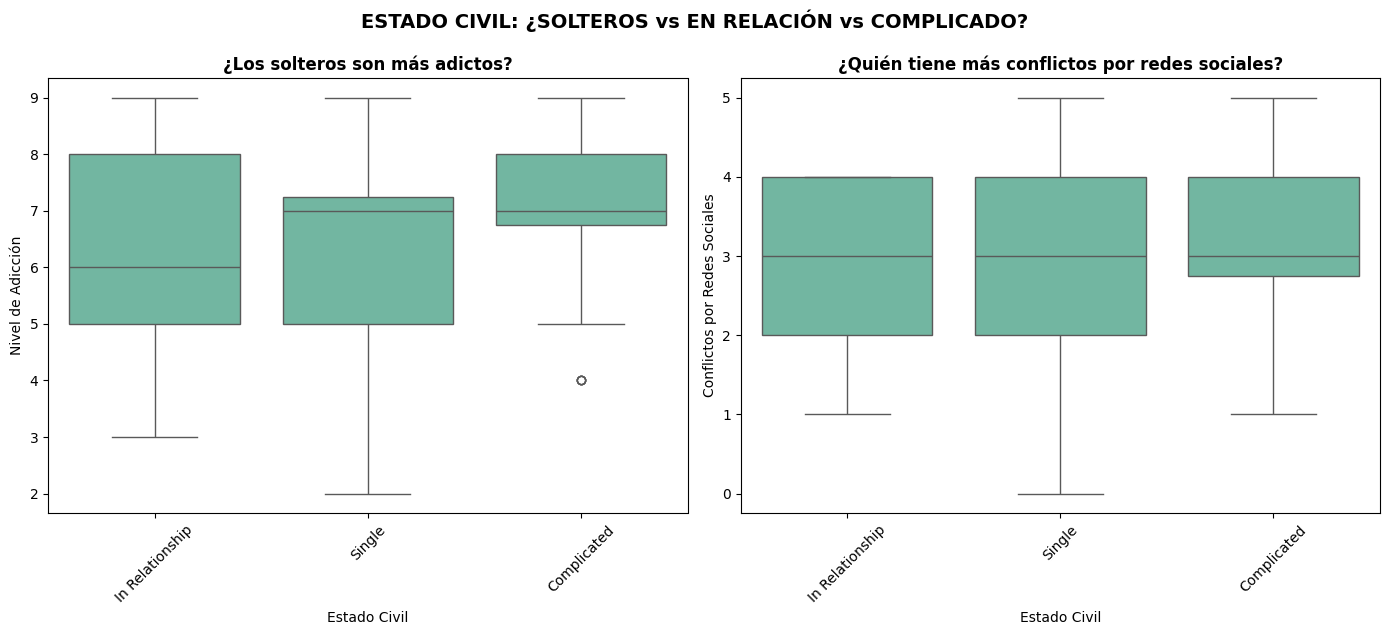

In [30]:
# Ver estados civiles
estados_civiles = df['Relationship_Status'].value_counts()
print("ESTADOS CIVILES EN NUESTRA MUESTRA:")
for estado, cantidad in estados_civiles.items():
    print(f"   • {estado}: {cantidad} estudiantes")

# Estadísticas por estado civil
print("\nADICCIÓN Y CONFLICTOS POR ESTADO CIVIL:")
for estado in df['Relationship_Status'].unique():
    grupo = df[df['Relationship_Status'] == estado]
    adiccion = grupo['Addicted_Score'].mean()
    conflictos = grupo['Conflicts_Over_Social_Media'].mean()
    print(f"   {estado}: Adicción {adiccion:.2f}/10, Conflictos {conflictos:.1f}")

# Gráfico por estado civil
plt.figure(figsize=(14, 6))

# Subplot 1: Adicción por estado civil
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='Relationship_Status', y='Addicted_Score')
plt.title('¿Los solteros son más adictos?', fontweight='bold')
plt.xlabel('Estado Civil')
plt.ylabel('Nivel de Adicción')
plt.xticks(rotation=45)

# Subplot 2: Conflictos por estado civil
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Relationship_Status', y='Conflicts_Over_Social_Media')
plt.title('¿Quién tiene más conflictos por redes sociales?', fontweight='bold')
plt.xlabel('Estado Civil')
plt.ylabel('Conflictos por Redes Sociales')
plt.xticks(rotation=45)

plt.tight_layout()
plt.suptitle('ESTADO CIVIL: ¿SOLTEROS vs EN RELACIÓN vs COMPLICADO?', fontsize=14, fontweight='bold', y=1.05)
plt.show()

### ¿Qué grupos son mas vulnerables a la adicción?

In [31]:

# Calcular promedios por grupo
genero_mas_adicto = df.groupby('Gender')['Addicted_Score'].mean().idxmax()
valor_genero = df.groupby('Gender')['Addicted_Score'].mean().max()

nivel_mas_adicto = df.groupby('Academic_Level')['Addicted_Score'].mean().idxmax()
valor_nivel = df.groupby('Academic_Level')['Addicted_Score'].mean().max()

plataforma_mas_adictiva = df.groupby('Most_Used_Platform')['Addicted_Score'].mean().idxmax()
valor_plataforma = df.groupby('Most_Used_Platform')['Addicted_Score'].mean().max()

estado_mas_adicto = df.groupby('Relationship_Status')['Addicted_Score'].mean().idxmax()
valor_estado = df.groupby('Relationship_Status')['Addicted_Score'].mean().max()

print(f"   Género más adicto: {genero_mas_adicto} ({valor_genero:.2f}/10)")
print(f"   Nivel académico más adicto: {nivel_mas_adicto} ({valor_nivel:.2f}/10)")
print(f"   Plataforma más adictiva: {plataforma_mas_adictiva} ({valor_plataforma:.2f}/10)")
print(f"   Estado civil más adicto: {estado_mas_adicto} ({valor_estado:.2f}/10)")

print(f"\nDIFERENCIAS MÁS NOTABLES:")

# Calcular las diferencias más grandes
dif_genero = abs(df[df['Gender']=='Male']['Addicted_Score'].mean() -
                df[df['Gender']=='Female']['Addicted_Score'].mean())

print(f"   Diferencia entre géneros: {dif_genero:.2f} puntos")

# Plataforma con más vs menos adicción
plataforma_menos = df.groupby('Most_Used_Platform')['Addicted_Score'].mean().idxmin()
dif_plataforma = df.groupby('Most_Used_Platform')['Addicted_Score'].mean().max() - \
                df.groupby('Most_Used_Platform')['Addicted_Score'].mean().min()

print(f"   Diferencia entre plataformas: {dif_plataforma:.2f} puntos")
print(f"     ({plataforma_mas_adictiva} vs {plataforma_menos})")



   Género más adicto: Female (6.52/10)
   Nivel académico más adicto: High School (8.04/10)
   Plataforma más adictiva: WhatsApp (7.46/10)
   Estado civil más adicto: Complicated (7.03/10)

DIFERENCIAS MÁS NOTABLES:
   Diferencia entre géneros: 0.16 puntos
   Diferencia entre plataformas: 4.46 puntos
     (WhatsApp vs LINE)


## Creando un modelo de predicción.

In [32]:
# Librerias
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')


In [33]:
#Preparación de los datos para el modelo

# Se crea una copia para no modificar el dataset original
df_modelo = df.copy()

# Convertir variables categóricas a numéricas
print("VARIABLES CATEGÓRICAS A CONVERTIR:")
categoricas = ['Gender', 'Academic_Level', 'Most_Used_Platform', 'Relationship_Status']

# Crear encoders para cada variable categórica
encoders = {}
for col in categoricas:
    if col in df_modelo.columns:
        encoder = LabelEncoder()
        df_modelo[f'{col}_encoded'] = encoder.fit_transform(df_modelo[col])
        encoders[col] = encoder
        print(f"   {col}: {len(encoder.classes_)} categorías")

# Seleccionar variables predictoras (features)
features = [
    'Avg_Daily_Usage_Hours',
    'Mental_Health_Score',
    'Conflicts_Over_Social_Media',
    'Gender_encoded',
    'Academic_Level_encoded',
    'Most_Used_Platform_encoded',
    'Relationship_Status_encoded'
]

# Filtrar solo las features que existen en el dataset
features_disponibles = [f for f in features if f in df_modelo.columns]
print(f"\nVARIABLES PREDICTORAS SELECCIONADAS ({len(features_disponibles)}):")
for i, feature in enumerate(features_disponibles, 1):
    print(f"   {i}. {feature}")

# Variable objetivo (lo que queremos predecir)
target = 'Addicted_Score'
print(f"\nVARIABLE OBJETIVO: {target}")

# Verificar que no hay valores faltantes
print(f"\nVERIFICANDO CALIDAD DE DATOS:")
print(f"   • Filas totales: {len(df_modelo)}")
print(f"   • Valores faltantes en objetivo: {df_modelo[target].isna().sum()}")
print(f"   • Valores faltantes en predictores: {df_modelo[features_disponibles].isna().sum().sum()}")


VARIABLES CATEGÓRICAS A CONVERTIR:
   Gender: 2 categorías
   Academic_Level: 3 categorías
   Most_Used_Platform: 12 categorías
   Relationship_Status: 3 categorías

VARIABLES PREDICTORAS SELECCIONADAS (7):
   1. Avg_Daily_Usage_Hours
   2. Mental_Health_Score
   3. Conflicts_Over_Social_Media
   4. Gender_encoded
   5. Academic_Level_encoded
   6. Most_Used_Platform_encoded
   7. Relationship_Status_encoded

VARIABLE OBJETIVO: Addicted_Score

VERIFICANDO CALIDAD DE DATOS:
   • Filas totales: 705
   • Valores faltantes en objetivo: 0
   • Valores faltantes en predictores: 0


## Dividiendo los datos en entrenamiento y prueba

In [34]:
print("\nSeparando los Datos")


# Preparando X (predictores) y y (objetivo)
X = df_modelo[features_disponibles]
y = df_modelo[target]

# Dividiendo en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"DIVISIÓN DE DATOS:")
print(f"   • Entrenamiento: {len(X_train)} estudiantes ({len(X_train)/len(df_modelo)*100:.1f}%)")
print(f"   • Prueba: {len(X_test)} estudiantes ({len(X_test)/len(df_modelo)*100:.1f}%)")
print(f"   • Total: {len(df_modelo)} estudiantes")

print(f"\nESTADÍSTICAS DEL OBJETIVO:")
print(f"   • Promedio en entrenamiento: {y_train.mean():.2f}")
print(f"   • Promedio en prueba: {y_test.mean():.2f}")
print(f"   • Rango: {y.min():.1f} - {y.max():.1f}")


Separando los Datos
DIVISIÓN DE DATOS:
   • Entrenamiento: 564 estudiantes (80.0%)
   • Prueba: 141 estudiantes (20.0%)
   • Total: 705 estudiantes

ESTADÍSTICAS DEL OBJETIVO:
   • Promedio en entrenamiento: 6.45
   • Promedio en prueba: 6.37
   • Rango: 2.0 - 9.0


In [36]:
#Entrenando con distintos modelos

# Modelo 1: Regresión Lineal (Simple)
print("MODELO 1: REGRESIÓN LINEAL")
modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train, y_train)

# Predicciones del modelo lineal
y_pred_lineal = modelo_lineal.predict(X_test)

# Métricas del modelo lineal
mse_lineal = mean_squared_error(y_test, y_pred_lineal)
r2_lineal = r2_score(y_test, y_pred_lineal)
mae_lineal = mean_absolute_error(y_test, y_pred_lineal)

print(f"   • Error cuadrático medio: {mse_lineal:.3f}")
print(f"   • R^2 (precisión): {r2_lineal:.3f} ({r2_lineal*100:.1f}%)")
print(f"   • Error absoluto medio: {mae_lineal:.3f}")

# Modelo 2: Random Forest (Más sofisticado)
print(f"\nMODELO 2: RANDOM FOREST")
modelo_forest = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_forest.fit(X_train, y_train)

# Predicciones del modelo forest
y_pred_forest = modelo_forest.predict(X_test)

# Métricas del modelo forest
mse_forest = mean_squared_error(y_test, y_pred_forest)
r2_forest = r2_score(y_test, y_pred_forest)
mae_forest = mean_absolute_error(y_test, y_pred_forest)

print(f"   • Error cuadrático medio: {mse_forest:.3f}")
print(f"   • R^2 (precisión): {r2_forest:.3f} ({r2_forest*100:.1f}%)")
print(f"   • Error absoluto medio: {mae_forest:.3f}")


MODELO 1: REGRESIÓN LINEAL
   • Error cuadrático medio: 0.143
   • R^2 (precisión): 0.943 (94.3%)
   • Error absoluto medio: 0.331

MODELO 2: RANDOM FOREST
   • Error cuadrático medio: 0.057
   • R^2 (precisión): 0.977 (97.7%)
   • Error absoluto medio: 0.091


In [37]:
# Comparando modelos
# Comparación de modelos
if r2_forest > r2_lineal:
    mejor_modelo = "Random Forest"
    mejor_r2 = r2_forest
    mejor_mae = mae_forest
    predicciones_mejor = y_pred_forest
    modelo_ganador = modelo_forest
else:
    mejor_modelo = "Regresión Lineal"
    mejor_r2 = r2_lineal
    mejor_mae = mae_lineal
    predicciones_mejor = y_pred_lineal
    modelo_ganador = modelo_lineal

print(f"MODELO GANADOR: {mejor_modelo}")
print(f"   • Precisión: {mejor_r2:.3f} ({mejor_r2*100:.1f}%)")
print(f"   • Error promedio: {mejor_mae:.2f} puntos")

if mejor_r2 > 0.7:
    print("EXCELENTE: El modelo es muy confiable")
elif mejor_r2 > 0.5:
    print("BUENO: El modelo es bastante confiable")
elif mejor_r2 > 0.3:
    print("MODERADO: El modelo tiene precisión limitada")
else:
    print("BAJO: El modelo necesita mejoras")

MODELO GANADOR: Random Forest
   • Precisión: 0.977 (97.7%)
   • Error promedio: 0.09 puntos
EXCELENTE: El modelo es muy confiable
